# Analysis of Iris Species Classification using Tree-Based Algorithms

## Abstract
This notebook presents a comparative study of two supervised learning algorithms—**Decision Tree** and **Random Forest**—applied to the Iris dataset. The objective is to classify Iris flowers into three species (*Iris setosa*, *Iris versicolor*, and *Iris virginica*) based on sepal and petal dimensions. We evaluate model performance using accuracy metrics, confusion matrices, and precision-recall scores to determine the efficacy of ensemble methods over single decision trees in this context.

## 1. Data Acquisition and Exploratory Data Analysis (EDA)

The analysis begins by loading the dataset and performing an initial inspection. Preprocessing steps include removing non-predictive features, such as the `Id` column, to prevent noise injection.

We utilize **Pair Plots** to visualize the pairwise relationships between features. This visualization is crucial for:
1.  **Class Separability**: Identifying which features (e.g., Petal Length vs. Petal Width) provide the clearest boundaries between species.
2.  **Distribution Analysis**: Observing the univariate distribution of each feature on the diagonal.

In [9]:
import pandas as pd
import numpy as np

csv_path = '../datasets/Iris.csv'
df = pd.read_csv(csv_path)
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
128,129,6.4,2.8,5.6,2.1,Iris-virginica
87,88,6.3,2.3,4.4,1.3,Iris-versicolor
74,75,6.4,2.9,4.3,1.3,Iris-versicolor
120,121,6.9,3.2,5.7,2.3,Iris-virginica
89,90,5.5,2.5,4.0,1.3,Iris-versicolor


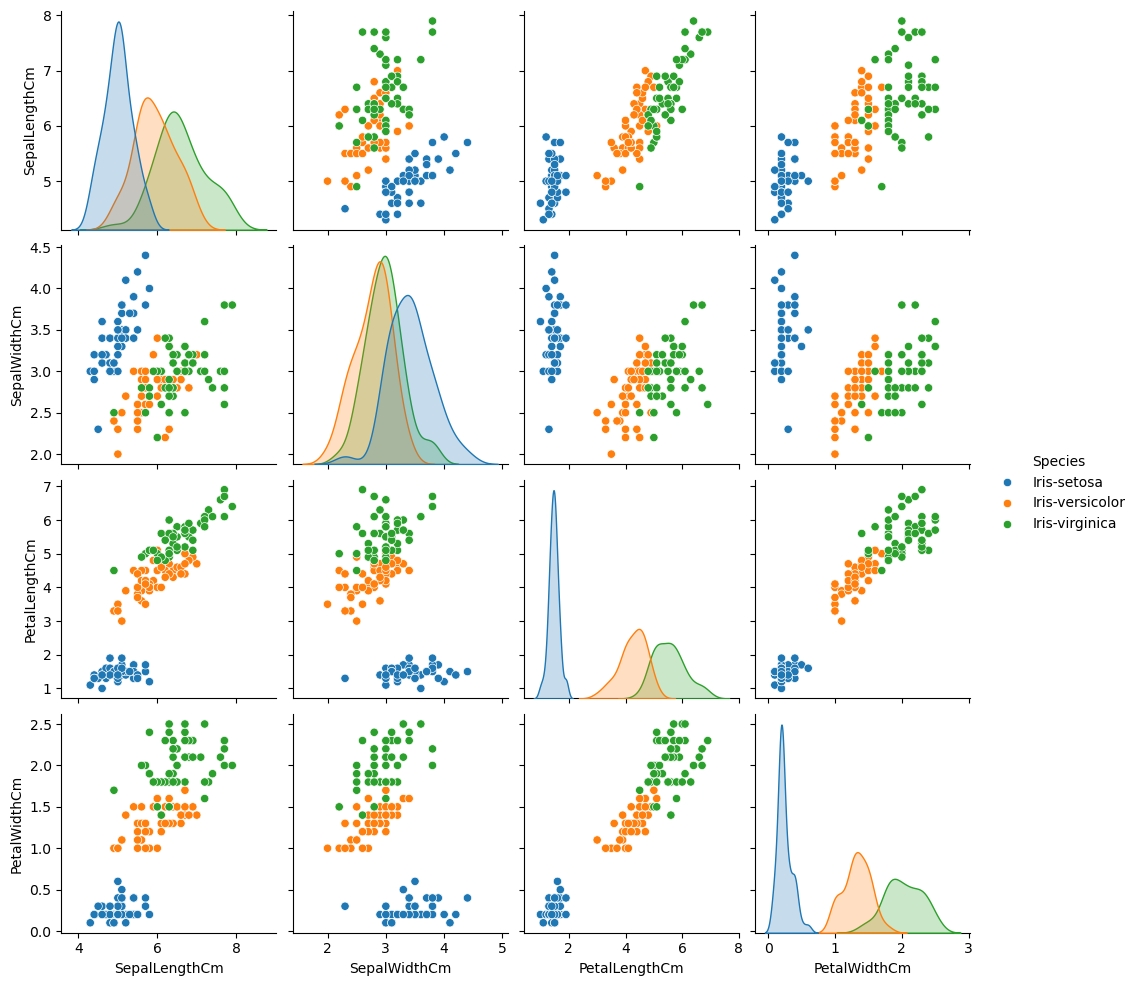

In [10]:
import seaborn as sns
df.drop(columns=['Id'], inplace=True)
sns.pairplot(df, hue='Species')

## 2. Decision Tree Classifier Implementation

We partition the data into training (70%) and testing (30%) sets to ensure an unbiased evaluation of the model's generalization capabilities.

### Model Specification
A **Decision Tree** classifier is instantiated with a `max_depth` of 3. This hyperparameter constraint is applied to:
*   **Prevent Overfitting**: Limiting the tree depth forces the model to learn more general patterns rather than memorizing the training noise.
*   **Interpretability**: Shallower trees are easier to visualize and explain.

### Visualization and Evaluation
Post-training, we visualize the tree structure to understand the decision rules (based on Gini impurity reduction) and generate a **Confusion Matrix** to quantify misclassifications.

In [11]:
df['Species'].value_counts()
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Species'])
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


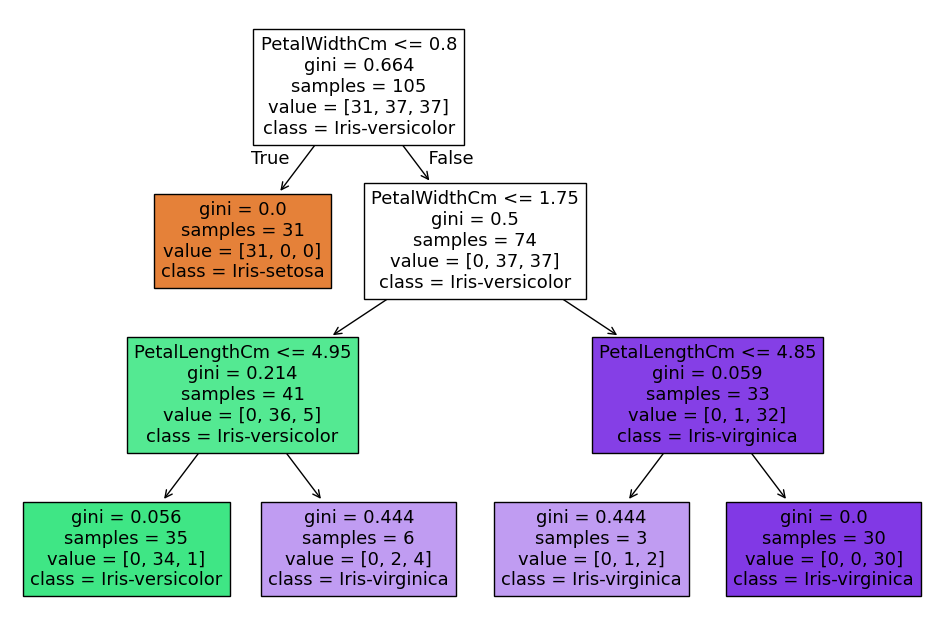

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=X.columns, class_names=model.classes_)
plt.show()

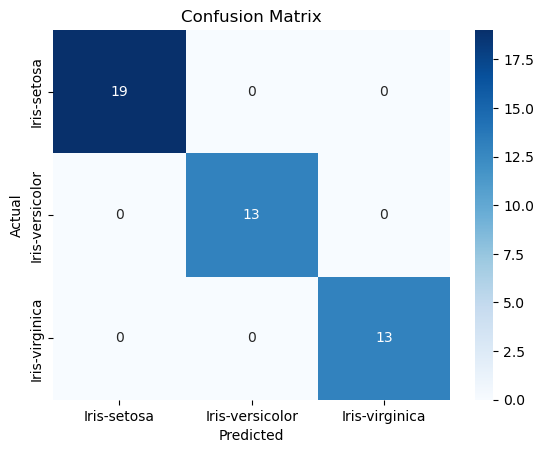

In [13]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 3. Random Forest Ensemble Implementation

To address the potential high variance of a single Decision Tree, we employ a **Random Forest Classifier**.

### Methodology
*   **Ensemble Learning**: This method constructs a multitude of decision trees at training time and outputs the mode of the classes (classification) of the individual trees.
*   **Hyperparameters**: We utilize `n_estimators=100` (100 trees) and maintain `max_depth=3` for consistency with the baseline Decision Tree model.

Most distinctively, Random Forests introduce randomness in feature selection at each split, typically resulting in a more robust model that generalizes better on unseen data.

In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

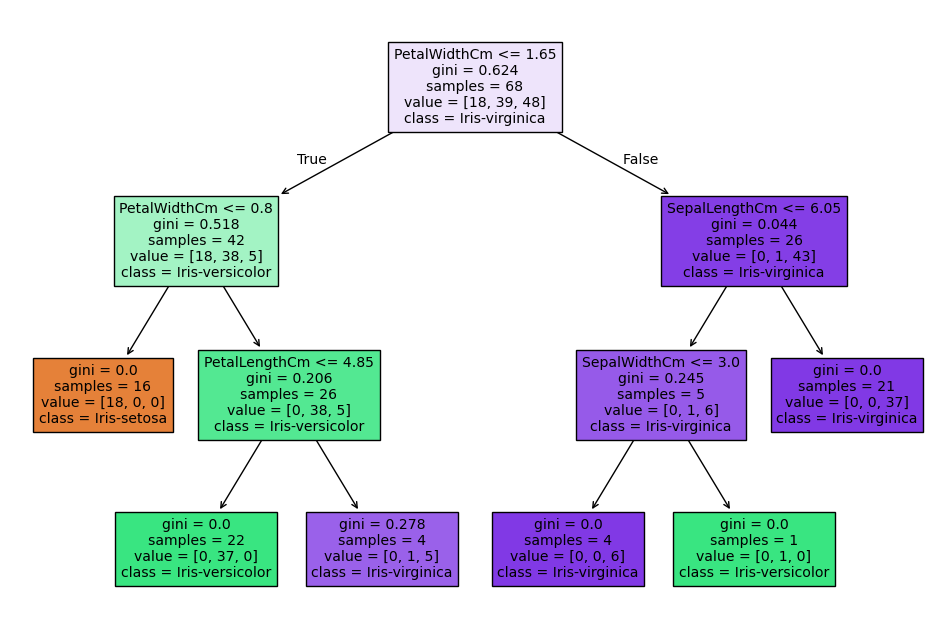

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(rf_model.estimators_[0], filled=True, feature_names=X.columns, class_names=rf_model.classes_)
plt.show()

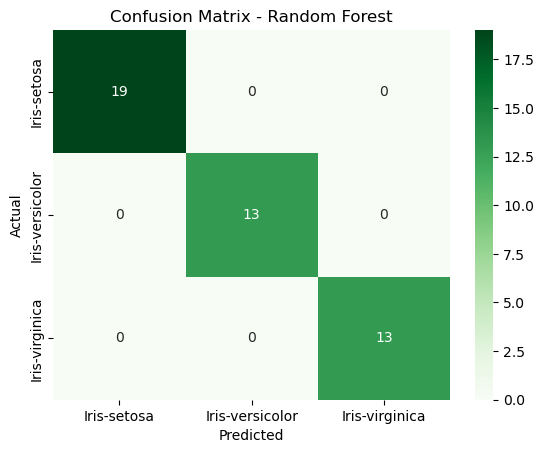

In [ ]:
cm_rf = confusion_matrix(y_test, rf_y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

## 4. Comparative Results and Conclusion

The final stage involves a side-by-side comparison of the Decision Tree and Random Forest models using quantitative metrics.

### Key Metrics
*   **Precision & Recall**: To monitor false positives and false negatives, particularly important if class imbalance existed.
*   **F1-Score**: The harmonic mean of precision and recall.

### Conclusion
By comparing the classification reports, we can assess whether the ensemble approach of the Random Forest yields a statistically significant improvement over the single Decision Tree. Typically, on the Iris dataset, both models perform exceptionally well, with occasional misclassification occurring only between the overlapping *Versicolor* and *Virginica* classes. If the Random Forest shows higher accuracy or F1-scores, it confirms the value of variance reduction techniques in classification tasks.

In [16]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred))
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

Decision Tree Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Random Forest Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

